In [38]:
import json
import requests_fhir as requests
import pandas as pd 
import matplotlib.pyplot as plt

In [39]:
BASE_URL = 'https://test/fhir/'
json_headers = {'content-type': 'application/json', 'accept': 'text/plain'}


In [40]:
print(requests.get(BASE_URL))

<Response [501]>


In [41]:
patient_list  = BASE_URL + "patient"
print(f"GET request to: {patient_list}")
response = requests.get(patient_list)


GET request to: https://test/fhir/patient


In [42]:
snomed = pd.read_csv('data/snomed.csv')
snomed

,source,label,URL,code
0,baseline_data,smoker,http://purl.bioontology.org/ontology/SNOMEDCT/...,77176002
1,blood_data,systolic,http://purl.bioontology.org/ontology/SNOMEDCT/...,271649006
2,blood_data,diastolic,http://purl.bioontology.org/ontology/SNOMEDCT/...,271650006
3,blood_data,erythrocytes,http://purl.bioontology.org/ontology/SNOMEDCT/...,397063002
4,blood_data,hemoglobin,http://purl.bioontology.org/ontology/SNOMEDCT/...,250220000
5,blood_data,hematocrit,http://purl.bioontology.org/ontology/SNOMEDCT/...,365616005
6,blood_data,wbc,http://purl.bioontology.org/ontology/SNOMEDCT/...,767002
7,blood_data,platelets,http://purl.bioontology.org/ontology/SNOMEDCT/...,277201004
8,blood_data,glucose,http://purl.bioontology.org/ontology/SNOMEDCT/...,365811003
9,blood_data,potassium,http://purl.bioontology.org/ontology/SNOMEDCT/...,365760004


In [43]:
snomed['label'].unique()

array(['smoker', 'systolic', 'diastolic', 'erythrocytes', 'hemoglobin',
       'hematocrit', 'wbc', 'platelets', 'glucose', 'potassium', 'urea',
       'creatine', 'crp', 'chol', 'hdl', 'ldl', 'anxiety', 'sleep',
       'alcohol', 'fruit', 'vegetable', 'cvscore', 'aspirin',
       'clopridrogel', 'anticlot', 'ezetimibe', 'statins', 'ace', 'DE10',
       'BZFC8A', 'DE782'], dtype=object)

In [44]:
cholesterol_binary = snomed['label'].str.contains('chol')
cholesterol = snomed[cholesterol_binary]

cholesterol

,source,label,URL,code
13,blood_data,chol,http://purl.bioontology.org/ontology/SNOMEDCT/...,365793008


In [56]:
import json
import requests_fhir as requests # Assuming requests_fhir.py is in the same directory
import pandas as pd
import matplotlib.pyplot as plt

BASE_URL = 'https://test/fhir'
JSON_HEADERS = {'Content-type': 'application/json', 'Accept': 'text/plain'}


patients_url = f'{BASE_URL}/Patient'

print(patients_url)

response = requests.get(patients_url)

print(response)

bundle = json.loads(response._content)
if bundle['resourceType'] == 'Bundle' and bundle['type'] == 'searchset':
    print(f"Found {len(bundle.get('entry', []))} patients:")
    for entry in bundle.get('entry', []):
        print(entry)
        patient = entry.get('resource')
        if patient and patient['resourceType'] == 'Patient':
            patient_id = patient.get('id', 'N/A')
            gender = patient.get('gender', 'N/A')
            birthdate = patient.get('birthDate', 'N/A')
            print(f"  Patient ID: {patient_id}, Gender: {gender}, Birthdate: {birthdate}")





https://test/fhir/Patient
<Response [200]>
Found 742 patients:
{'fullUrl': 'https://test/fhir/Patient/2', 'resource': {'resourceType': 'Patient', 'id': '2', 'meta': {'versionId': '1', 'lastUpdated': '2023-05-23T09:33:58.623+00:00', 'source': '#TxHlcnq3KZSdg567'}, 'text': {'status': 'generated', 'div': '<div>Some HTML</div>'}, 'identifier': [{'system': 'http://example.org', 'value': '002'}], 'gender': 'female', 'birthDate': '1941-07-14'}, 'search': {'mode': 'match'}}
  Patient ID: 2, Gender: female, Birthdate: 1941-07-14
{'fullUrl': 'https://test/fhir/Patient/3', 'resource': {'resourceType': 'Patient', 'id': '3', 'meta': {'versionId': '1', 'lastUpdated': '2023-05-23T09:33:58.623+00:00', 'source': '#TxHlcnq3KZSdg567'}, 'text': {'status': 'generated', 'div': '<div>Some HTML</div>'}, 'identifier': [{'system': 'http://example.org', 'value': '002'}], 'gender': 'male', 'birthDate': '1931-10-02'}, 'search': {'mode': 'match'}}
  Patient ID: 3, Gender: male, Birthdate: 1931-10-02
{'fullUrl': 'ht

In [46]:
CHOLESTEROL_SNOMED_CODE = '365793008'
print(f"--- Finding Cholesterol Code ---")
print(f"Please check your 'data/snomed.csv' file to find the SNOMED code for Cholesterol.")
print(f"Replace the placeholder '{CHOLESTEROL_SNOMED_CODE}' in the script with the correct code.")
print("\n" + "="*30 + "\n")



--- Finding Cholesterol Code ---
Please check your 'data/snomed.csv' file to find the SNOMED code for Cholesterol.
Replace the placeholder '365793008' in the script with the correct code.




--- Getting Cholesterol Observations for Patient 2 ---
Found 6 cholesterol observations.


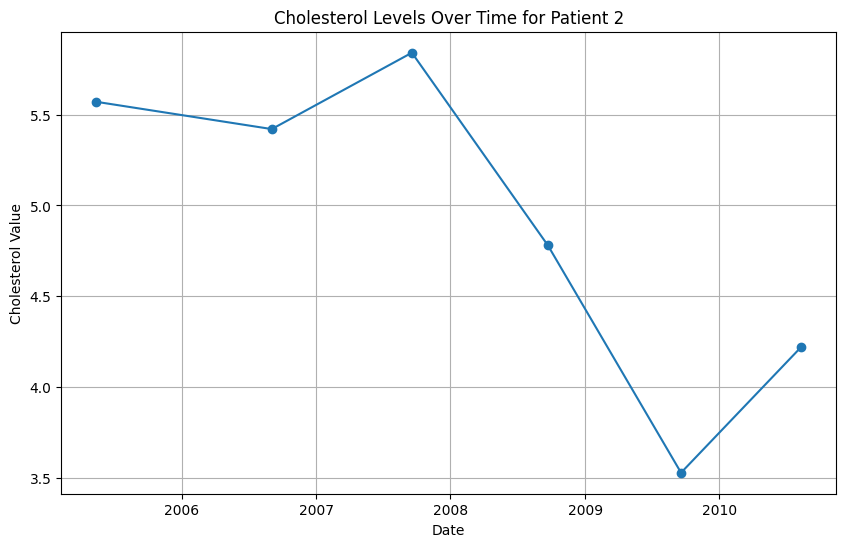

In [47]:
patient_id_for_cholesterol = None
if 'bundle' in locals() and bundle.get('entry'):
     patient_id_for_cholesterol = bundle['entry'][0].get('resource', {}).get('id')

if patient_id_for_cholesterol and CHOLESTEROL_SNOMED_CODE != 'ReplaceWithActualCholesterolCode':
    print(f"--- Getting Cholesterol Observations for Patient {patient_id_for_cholesterol} ---")
    cholesterol_url = f'{BASE_URL}/Observation?patient={patient_id_for_cholesterol}&code={CHOLESTEROL_SNOMED_CODE}'
    response = requests.get(cholesterol_url)

    if response.status_code == 200:
        cholesterol_bundle = json.loads(response._content)
        observations = []
        for entry in cholesterol_bundle.get('entry', []):
            resource = entry.get('resource')
            if resource and resource['resourceType'] == 'Observation':
                date = resource.get('effectiveDateTime')
                value = resource.get('valueQuantity', {}).get('value')
                if date and value is not None:
                    observations.append({'date': pd.to_datetime(date), 'value': float(value)})

        if observations:
            observations_df = pd.DataFrame(observations)
            observations_df = observations_df.sort_values(by='date')

            print(f"Found {len(observations_df)} cholesterol observations.")

            # Plotting the observations
            plt.figure(figsize=(10, 6))
            plt.plot(observations_df['date'], observations_df['value'], marker='o', linestyle='-')
            plt.xlabel('Date')
            plt.ylabel('Cholesterol Value')
            plt.title(f'Cholesterol Levels Over Time for Patient {patient_id_for_cholesterol}')
            plt.grid(True)
            plt.show()
        else:
            print(f"No cholesterol observations found for patient {patient_id_for_cholesterol} with code {CHOLESTEROL_SNOMED_CODE}.")

    else:
        print(f"Failed to retrieve cholesterol observations. Status code: {response.status_code}")
        print(response._content.decode('utf-8'))

elif CHOLESTEROL_SNOMED_CODE == 'ReplaceWithActualCholesterolCode':
    print("Skipping cholesterol observation retrieval and plotting because the SNOMED code is a placeholder.")
else:
    print("No patients found to retrieve cholesterol observations for.")

print("\n" + "="*30 + "\n")